In [261]:
'''
Complete Tactile Feedback code
'''
'''
Start of Train-Test results
'''

# --- Import Modules --- #
import sys, statistics, time, string, random
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import pandas as pd
import pickle 
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold

from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef
from sklearn.utils.multiclass import unique_labels

sys.path.insert(0, 'C:/Users/dema2/OneDrive/Desktop/PhD/Tactile-Feedback-Repo/Reflex-Fuzzy-Network')
from RFMN import ReflexFuzzyNeuroNetwork

np.set_printoptions(threshold=5)


In [262]:
'''
Data split for Iris.csv
'''
data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\SaveModel\\Iris_feedback.csv')

data = data.iloc[:,1:]
# column names to use
# names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Label']

# read the dataset from the URL
# dataset = pd.read_csv(data, names=names)
# dataset = pd.read_csv(data)  
data.head()




# data = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\Reflex-Fuzzy-Network\\Arduino_train_test_D_F_W.csv')

# data = data.iloc[:,1:]

# print(data, "\n\n\n")

# X = data.iloc[:,:-1] # for every y (class) we get a 4-D array. E.g., I'm in the 5th dimension. 
# y = data.iloc[:,-1] # same as saying y coresponds to the respective classes. E.g., w = 1,2 or 3.

# print(X, "\n\n\n")
# print(y, "\n\n\n")


,sepal-length,sepal-width,petal-length,petal-width,Label
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


In [263]:
# separate the independent and dependent features
X = data.iloc[:, :-1]
y = data.iloc[:, 4]
print(X)
print(y)


# X = data.iloc[:,:-1]
# y = data.iloc[:,-1]

     sepal-length  sepal-width  petal-length  petal-width
0             5.1          3.5           1.4          0.2
1             4.9          3.0           1.4          0.2
2             4.7          3.2           1.3          0.2
3             4.6          3.1           1.5          0.2
4             5.0          3.6           1.4          0.2
..            ...          ...           ...          ...
145           6.7          3.0           5.2          2.3
146           6.3          2.5           5.0          1.9
147           6.5          3.0           5.2          2.0
148           6.2          3.4           5.4          2.3
149           5.9          3.0           5.1          1.8

[150 rows x 4 columns]
0      1
1      1
2      1
3      1
4      1
      ..
145    3
146    3
147    3
148    3
149    3
Name: Label, Length: 150, dtype: int64


In [265]:
scaler_min_max = MinMaxScaler(feature_range=(0.001, .99))
X_norm = scaler_min_max.fit_transform(X)

print(X_norm)


[[0.22077778 0.619125   0.06805085 0.04220833]
 [0.16583333 0.41308333 0.06805085 0.04220833]
 [0.11088889 0.4955     0.05128814 0.04220833]
 ...
 [0.60538889 0.41308333 0.7050339  0.78395833]
 [0.52297222 0.57791667 0.73855932 0.90758333]
 [0.44055556 0.41308333 0.68827119 0.70154167]]


In [266]:
# Split the data between train and test. 
X_train, X_test, y_train, y_test = train_test_split( X_norm, y, test_size=0.33, random_state=42) # Split the data to 33% to test, and 66% to training
                                            #These value come in four 66X1 matrices for X_train and X_test
                                            # and one 66X1 matrix for y_train and y_test. 
                                            # random state = 42
print(" This is X_train \n", X_train, "\n" )
print(" This is X_test \n", X_test, "\n" )
print(" This is y_train \n", y_train, "\n" )
print(" This is y_test \n", y_test, "\n" )


print("X train shape \n", X_train.shape)
print("Y train shape\n", y_train.shape)

print("X test shape \n", X_test.shape)
print("Y test shape\n", y_test.shape)

 This is X_train 
 [[0.38561111 0.371875   0.53740678 0.4955    ]
 [0.90758333 0.41308333 0.93971186 0.82516667]
 [0.35813889 0.41308333 0.58769492 0.57791667]
 ...
 [0.41308333 0.82516667 0.03452542 0.04220833]
 [0.41308333 0.24825    0.50388136 0.45429167]
 [0.77022222 0.41308333 0.82237288 0.82516667]] 

 This is X_test 
 [[0.4955     0.33066667 0.62122034 0.45429167]
 [0.38561111 0.74275    0.11833898 0.08341667]
 [0.93505556 0.24825    0.99       0.90758333]
 ...
 [0.57791667 0.45429167 0.75532203 0.70154167]
 [0.63286111 0.41308333 0.5709322  0.53670833]
 [0.79769444 0.66033333 0.85589831 0.99      ]] 

 This is y_train 
 96     2
105    3
66     2
0      1
122    3
      ..
71     2
106    3
14     1
92     2
102    3
Name: Label, Length: 100, dtype: int64 

 This is y_test 
 73     2
18     1
118    3
78     2
76     2
31     1
64     2
141    3
68     2
82     2
110    3
12     1
36     1
9      1
19     1
56     2
104    3
69     2
55     2
132    3
29     1
127    3
26     1

In [267]:
y_train, y_test = y_train.values, y_test.values # Transpose the y_train and y_test data. 
                                # Essentailly we go from a 66X1 matrices to a 1x66 matrices. 

                           
X_train, X_test = X_train.T, X_test.T # Transpose the X_train and X_test data. 
                                # Essentailly we go from four 66X1 matrices to four 1x66 matrices. 
# print(" This is X_train.T \n", X_train, "\n" )
# print(" This is X_test.T \n", X_test, "\n" )
# print(" This is y_train.values \n", y_train, "\n" )
# print(" This is y_test.values \n", y_test, "\n" )



print("X train \n", X_train)
print("Y train \n", y_train)
# print("X train len \n", len(X_train))
# print("Y train len \n", len(y_train))

print("X test 1 \n", X_test)
print("Y test 1 \n", y_test)
# # # print("X test len \n", len(X_test))
# print("Y test len \n", len(y_test))

print("X train shape \n", X_train.shape)
print("Y train shape\n", y_train.shape)
print("X test shape \n", X_test.shape)
print("Y test shape\n", y_test.shape)

X train 
 [[0.38561111 0.90758333 0.35813889 ... 0.41308333 0.41308333 0.77022222]
 [0.371875   0.41308333 0.41308333 ... 0.82516667 0.24825    0.41308333]
 [0.53740678 0.93971186 0.58769492 ... 0.03452542 0.50388136 0.82237288]
 [0.4955     0.82516667 0.57791667 ... 0.04220833 0.45429167 0.82516667]]
Y train 
 [2 3 2 ... 1 2 3]
X test 1 
 [[0.4955     0.38561111 0.93505556 ... 0.57791667 0.63286111 0.79769444]
 [0.33066667 0.74275    0.24825    ... 0.45429167 0.41308333 0.66033333]
 [0.62122034 0.11833898 0.99       ... 0.75532203 0.5709322  0.85589831]
 [0.45429167 0.08341667 0.90758333 ... 0.70154167 0.53670833 0.99      ]]
Y test 1 
 [2 1 3 ... 3 2 3]
X train shape 
 (4, 100)
Y train shape
 (100,)
X test shape 
 (4, 50)
Y test shape
 (50,)


In [268]:
# # # --- Declare network --- "
nn = ReflexFuzzyNeuroNetwork(gamma=1, theta=.1)

'''
X_trian after the X_train.T (transponse) is an "array [[column 1,column 2, column 3, column 4"]]
y_train after the y_train.values (transpose) is an array[column 5]
'''

# --- Train network --- #
nn.train(X_train, y_train)

print("Model is trained")


Model is trained


In [269]:
# --- Test Network --- #
y_predlr = nn.test(X_test,y_test)

print("done with predictions")

[2 1 3 ... 3 2 3]
done with predictions


In [270]:
# check results
print("confusion_matrix \n", confusion_matrix(y_test, y_predlr), "\n")
print("classification_report \n", classification_report(y_test, y_predlr), "\n")
     

confusion_matrix 
 [[19  0  0]
 [ 0 14  1]
 [ 0  0 16]] 

classification_report 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      0.93      0.97        15
           3       0.94      1.00      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50
 



In [271]:
np.set_printoptions(threshold=sys.maxsize)
unique_labels(y_test)

def plot(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

    return table


plot(y_test, y_predlr)

,Predicted 1,Predicted 2,Predicted 3
Actual 1,19,0,0
Actual 2,0,14,1
Actual 3,0,0,16


0.98


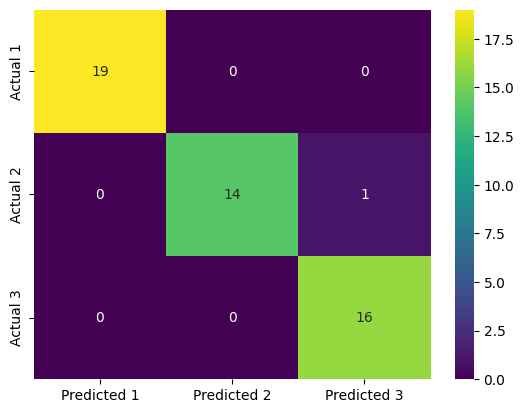

In [272]:
def plot2(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

    return sns.heatmap(table, annot = True, fmt = 'd', cmap= 'viridis')

plot2(y_test, y_predlr)

accuracy_score1 = accuracy_score(y_test, y_predlr)
print(accuracy_score1)


In [273]:
'''
Start of Cross validation results
'''

# initialise a StratifiedKFold object with 5 folds and
# declare the column that we which to group by which in this
# case is the column called "label"
n_splits=10
skf = StratifiedKFold(n_splits=n_splits, shuffle= True, random_state=42)

# y = data.iloc[:,-1] Same as below. 
target = data.loc[:,'Label']



In [274]:
# for each fold split the data into train and validation 
# sets and save the fold splits to csv
fold_no = 1
for train_index, val_index in skf.split(data, target):
    train = data.loc[train_index,:]
    val = data.loc[val_index,:]
    # train.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_D_F_W\\' + 'train_fold_' + str(fold_no) + '.csv')
    # val.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_D_F_W\\' + 'val_fold_' + str(fold_no) + '.csv')
    
    
    train.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'train_fold_' + str(fold_no) + '.csv')
    val.to_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'val_fold_' + str(fold_no) + '.csv')
    fold_no += 1

In [275]:
count = 1
accuracy_array = []
count_array = []
for fold_no in range(1,n_splits+1):

    newtrain = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'train_fold_' + str(fold_no) + '.csv')
    newval = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\Tactile-Feedback-Repo\\cross_val_data_iris\\' + 'val_fold_' + str(fold_no) + '.csv')

    newtrain = newtrain.iloc[:,1:]
    newval = newval.iloc[:,1:]


    X_train_val = newtrain.iloc[:,:-1]
    y_train_val = newtrain.iloc[:,-1]

    X_test_val = newval.iloc[:,:-1]
    y_test_val = newval.iloc[:,-1] 

    scaler_min_max = MinMaxScaler(feature_range=(0.01, .99))
    X_train_val = scaler_min_max.fit_transform(X_train_val)
    X_test_val = scaler_min_max.fit_transform(X_test_val)

    y_train_val, y_test_val = y_train_val.values, y_test_val.values 
    X_train_val, X_test_val = X_train_val.T, X_test_val.T 

    # # # --- Declare network --- "
    nn_val = ReflexFuzzyNeuroNetwork(gamma=2, theta=.001)

    # --- Train network --- #
    nn_val.train(X_train_val, y_train_val)
    y_predlr_val = nn_val.test(X_test_val,y_test_val)

    # check results
    print("confusion_matrix for count \n", confusion_matrix(y_test_val, y_predlr_val), "\n")
    print("classification_report for count \n", classification_report(y_test_val,y_predlr_val), "\n")

    np.set_printoptions(threshold=sys.maxsize)
    unique_labels(y_test_val)

    # def plot is the smae as plot2, except it looks better when analysing. 
    def plot(y_true, y_pred):
        labels = unique_labels(y_test_val)
        column = [f'Predicted {label}' for label in labels]
        indices = [f'Actual {label}' for label in labels]
        table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)
        return table
    
    def plot2(y_true, y_pred):
        labels = unique_labels(y_test_val)
        column = [f'Predicted {label}' for label in labels]
        indices = [f'Actual {label}' for label in labels]
        table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)
        return sns.heatmap(table, annot = True, fmt = 'd', cmap= 'viridis')
    
    plot(y_test_val, y_predlr_val)
    # plot2(y_test_val, y_predlr_val)

    accuracy_score1 = accuracy_score(y_test_val, y_predlr_val)
    accuracy_array.append(accuracy_score1)
    count_array.append(count)
    print("Accuracy for count", accuracy_score1)
    print("Done with count: ", count)

    # print("Accuracy array for count" + count + "\n", accuracy)
    # print("done with count array", count_array)

    count +=1


[1 1 1 1 1 3 3 2 2 2 3 3 3 3 3]
confusion_matrix for count 
 [[5 0 0]
 [0 3 2]
 [0 0 5]] 

classification_report for count 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         5
           2       1.00      0.60      0.75         5
           3       0.71      1.00      0.83         5

    accuracy                           0.87        15
   macro avg       0.90      0.87      0.86        15
weighted avg       0.90      0.87      0.86        15
 

Accuracy for count 0.8666666666666667
Done with count:  1
[1 1 1 1 1 2 2 2 3 2 3 3 3 3 3]
confusion_matrix for count 
 [[5 0 0]
 [0 4 1]
 [0 0 5]] 

classification_report for count 
               precision    recall  f1-score   support

           1       1.00      1.00      1.00         5
           2       1.00      0.80      0.89         5
           3       0.83      1.00      0.91         5

    accuracy                           0.93        15
   macro avg       0.94      0.93    

Accuracy out of loop:  [0.8666666666666667, 0.9333333333333333, 1.0, 0.9333333333333333, 0.8, 0.9333333333333333, 1.0, 0.9333333333333333, 0.8, 0.8]
Count out of loop:  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
std 0.0785674201318386
mean 0.9


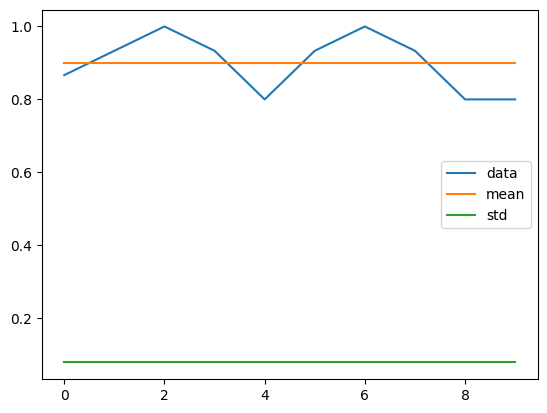

In [276]:
print("Accuracy out of loop: ", accuracy_array)
print("Count out of loop: ", count_array)
print("std", statistics.stdev(accuracy_array))
print("mean", statistics.mean(accuracy_array))

df = pd.DataFrame({
      'data': accuracy_array,
      'mean': [statistics.mean(accuracy_array) for i in range(1, len(accuracy_array)+1, 1)],
      'std': [statistics.stdev(accuracy_array) for i in range(1, len(accuracy_array)+1, 1)]})

df.plot()
plt.show()

In [278]:
'''
Using the pickle library/ pickle file to save the ML model
'''
import pickle 

# save the iris classification model as a pickle file
model_pk1_file = "iris_RFMN_model.pkl"

with open(model_pk1_file, 'wb') as file:
    pickle.dump(nn, file)

    

In [280]:
# load model from pickle file
with open(model_pk1_file, "rb") as file: 
    model = pickle.load(file)

# --- Test Network --- #
y_predict = nn.test(X_test,y_test)

print("done with predictions")

# check results
print(classification_report(y_test, y_predict))

[2 1 3 2 2 1 2 3 3 2 3 1 1 1 1 2 3 2 2 3 1 3 1 3 3 3 3 3 1 1 1 1 2 1 1 3 2
 1 1 1 3 2 2 1 1 2 3 3 2 3]
done with predictions
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        19
           2       1.00      0.93      0.97        15
           3       0.94      1.00      0.97        16

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50

